# Linear Models and Regularization

This notebook provides practical "recipes" for linear regression and regularization tasks in scikit-learn. Each recipe includes explanations, code examples, visualizations, best practices, and common pitfalls. We'll cover implementation, tuning, and evaluation of linear regression and regularization models.

## Introduction to Linear Models

### Getting ready
To get started, you'll notice that we're taking a familiar approach used in previous chapters by creating a synthetic dataset to demonstrate the concepts of linear models and regularization. scikit-learn provides a function called make_regression() that creates a synthetic regression dataset which we can further refine to create a more interesting dataset that includes some "noise" to make it more challenging.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 建立一個容易看出趨勢的 Regression 資料
# python 不會自己產生亂數
# 他是自己裡面有一張固定的亂數表
# random_state就是告訴python你從第幾個數字開始看
# 比如我現在要300個點 python就會從這個亂數表這個123的位置開始看300個數字
# 所以這300個數字保證看起來像亂數
# 也保證你今天跑  明天跑  這個亂數組合保證都一樣

X, y = make_regression(
    n_samples=300,       # 300 筆資料
    n_features=3,        # 只有 1 個特徵
    n_informative=1,     # 這個特徵就是有用的
    noise=2,            # 加一點雜訊，但不要太大
    random_state=123     # 因為random_state 有設 結果就是會一樣
)


# 建立 DataFrame
df = pd.DataFrame({
    'feature_0': X.ravel(),
    'target': y
})

df.to_csv('data/regression_data.csv', index=False)

# 畫圖
plt.figure(figsize=(10, 6))

plt.scatter(
    X[:, 0],
    y,
    alpha=0.6
)

plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')

plt.show()
df

ValueError: All arrays must be of the same length

### How to do it
Implementation of a linear regression model is straightforward. We'll use the train_test_split() function to split the data into training and testing sets, and then fit a linear regression model to the training data. Finally, we'll evaluate the model's performance using mean squared error (MSE) and R-squared (R^2) metrics. We can also visualize the model's predictions on the test set to see how well it fits the data.  
mean_squared_error (MSE)  預測錯多少  
r2_score (R²)  模型解釋了多少資料變化



Mean Squared Error: 1.35
R-squared: 1.00
Coefficient: 23.26
Intercept: -0.06
Regression Formula: y = 23.26x + -0.06


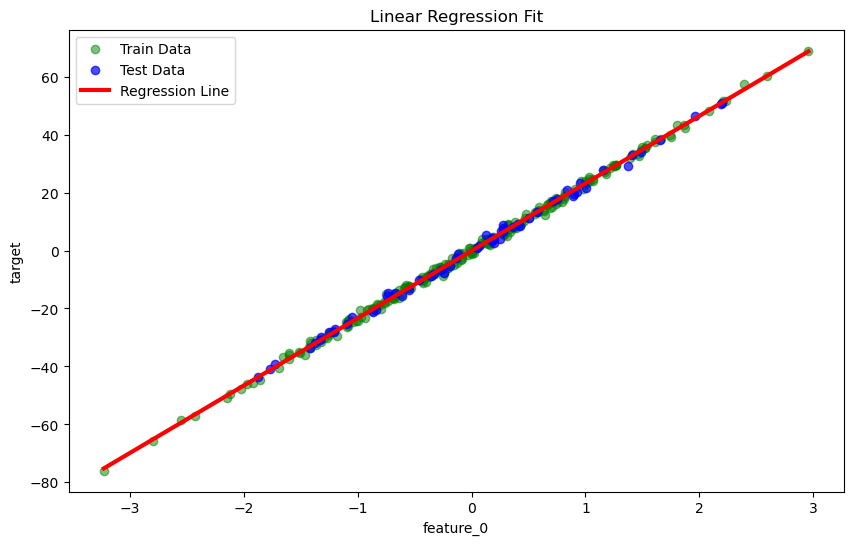

In [2]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 第一步 區分參考書 和 學測題
# train就式參考書和model 將來猛k的 
# test_size 就是你學測的分配比例 大概從0.05-0.25(百分之5-百分之25)
# 題目分群的過程都是隨機的 不是擬設0.02 test 前80題train 後20題 test
# 絕對都是隨機分配挑選
# 那設random_state就是為了 讓分配結果可以固定不變 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

# 建立一個空白的回歸模型

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
# fit就是訓練  訓練後 linear_model就把它讀了的參考書和答案  所思所學  轉化成系數  存在linear_model自己裡面


# 接著就把模型送去學測  所以只丟 x_test給它
# 叫模型預測答案
# y_pred就是預測的結果

y_pred = linear_model.predict(X_test)


# 模型的表現好壞　就是看　y_pred寫的答案　和　y_test（真正的答案）的比對結果囉
# 對regression來說  有幾個指標可以比較


# MSE：平均平方誤差
# 越小越好
mse = mean_squared_error(y_test, y_pred)

# R²：模型可以解釋資料變化的比例
# 越接近 1 越好
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

# 看一下模型學到的公式
print(f'Coefficient: {linear_model.coef_[0]:.2f}')
print(f'Intercept: {linear_model.intercept_:.2f}')

print(
    f'Regression Formula: '
    f'y = {linear_model.coef_[0]:.2f}x + '
    f'{linear_model.intercept_:.2f}'
)

plt.figure(figsize=(10, 6))

# 訓練資料
plt.scatter(
    X_train[:, 0],
    y_train,
    color='green',
    alpha=0.5,
    label='Train Data'
)

# 測試資料
plt.scatter(
    X_test[:, 0],
    y_test,
    color='blue',
    alpha=0.7,
    label='Test Data'
)


X_line = np.linspace(
    X.min(),
    X.max(),
    100
).reshape(-1, 1)

y_line = linear_model.predict(X_line)



plt.plot(
    X_line[:, 0],
    y_line,
    color='red',
    linewidth=3,
    label='Regression Line'
)

plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [ ]:
import joblib

# joblib 可以讓我們存檔此模型    需要時可以拿回來做預測
# 存檔
# 第一個參數就是剛剛續練完的模型
# 第二個參數就是存檔的檔案名
# 副檔名是.ProcessLookupError
# joblib.dump 就是把model的結構與參數   倒到檔案裏面


# 存檔
joblib.dump(linear_model, 'model/linear_regression_model.pkl')

['model/linear_regression_model.pkl']

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X, y = make_regression(
    n_samples=300,       # 300 筆資料
    n_features=3,        # 只有 1 個特徵
    n_informative=3,     # 這個特徵就是有用的
    noise=2,            # 加一點雜訊，但不要太大
    random_state=123     # 因為random_state 有設  所以你會跟我一樣
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

joblib.dump(linear_model, 'model/linear_regression_model.pkl')

Mean Squared Error: 3.46
R-squared: 1.00


['model/linear_regression_model.pkl']

In [11]:
import joblib

# 載入模型
# joblib.load 就是依照當初的結構與參數  蓋回來
loaded_model = joblib.load('model/linear_regression_model.pkl')

# 準備一筆資料
# model 收到的都是2D資料(只有X和Y)
# 第一層的[]代表資料集
# 第二層的[]代表一筆資料
X_new = [[100,12,13] ,
         [54,45,45] ,
         [12,42,12] ] 

# 預測
y_pred = loaded_model.predict(X_new)

print(y_pred)

[ 9326.52711232 10098.25290388  5055.89831313]


### How it works
Linear regression is a fundamental technique used to model relationships between a dependent variable (target) and one or more independent variables (features). The model assumes that there is a linear relationship between these variables

## Ridge and Lasso Regression

### Getting ready
In order to implement Ridge and Lasso regression, we'll use the Ridge and Lasso classes from the sklearn.linear_model module. These classes are similar to `LinearRegression()`, but they include an additional parameter called alpha, which controls the strength of the regularization. We can use the same dataset created in the previous section to demonstrate the implementation of Ridge and Lasso regression.  

Ridge 通常只是縮小係數的大小  
Lasso會真的讓一個係數變０  等於剔除這個特徵值


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 0. 建立亂數產生器
# ============================================================

# seed = 123
# 確保每次執行都會產生相同的資料
rng = np.random.default_rng(123)


# ============================================================
# 1. 建立 1000 筆房屋資料
# ============================================================

n_samples = 1000

# 真正會影響房價的 5 個特徵

# 房屋坪數
# 平均 30 坪，標準差 8 坪
size = rng.normal(
    loc=30,
    scale=8,
    size=n_samples
)

# 屋齡
# 平均 15 年，標準差 7 年
age = rng.normal(
    loc=15,
    scale=7,
    size=n_samples
)

# 距離市中心
# 平均 5 公里，標準差 2 公里
distance = rng.normal(
    loc=5,
    scale=2,
    size=n_samples
)

# 樓層
# 產生 1～19 樓的整數
floor = rng.integers(
    low=1,
    high=20,
    size=n_samples
)

# 地區平均所得
# 平均 60，標準差 15
income = rng.normal(
    loc=60,
    scale=15,
    size=n_samples
)


# ============================================================
# 2. 故意製造 Multicollinearity 共線性
# ============================================================

# size_copy1、size_copy2
# 基本上就是 size，只加入一點點誤差
# 因此這三個 feature 會高度相關

# loc=0：平均值是 0  scale=0.5：標準差是 0.5
size_copy1 = size + rng.normal(
    loc=0,
    scale=0.5,
    size=n_samples
)

size_copy2 = size + rng.normal(
    loc=0,
    scale=0.8,
    size=n_samples
)


# income 也故意製造兩個高度相關的 feature

income_copy1 = income + rng.normal(
    loc=0,
    scale=2,
    size=n_samples
)

income_copy2 = income + rng.normal(
    loc=0,
    scale=3,
    size=n_samples
)


# ============================================================
# 3. 製造完全沒有用的 Noise Features
# ============================================================

# 這五個 feature 完全不參與後面的房價計算
# 所以理論上它們的 coefficient 應該接近 0

noise_1 = rng.normal(0, 1, n_samples)
noise_2 = rng.normal(0, 1, n_samples)
noise_3 = rng.normal(0, 1, n_samples)
noise_4 = rng.normal(0, 1, n_samples)
noise_5 = rng.normal(0, 1, n_samples)


# ============================================================
# 4. 組合成 DataFrame
# ============================================================

X = pd.DataFrame({
    'size': size,
    'age': age,
    'distance': distance,
    'floor': floor,
    'income': income,

    # 高度相關特徵
    'size_copy1': size_copy1,
    'size_copy2': size_copy2,
    'income_copy1': income_copy1,
    'income_copy2': income_copy2,

    # 無效特徵
    'noise_1': noise_1,
    'noise_2': noise_2,
    'noise_3': noise_3,
    'noise_4': noise_4,
    'noise_5': noise_5
})


# ============================================================
# 5. 建立 Target：房價
# ============================================================

# 真正的房價公式：
#
# 坪數每增加 1 坪      → 房價 +30
# 屋齡每增加 1 年      → 房價 -8
# 距市中心每增加 1 km  → 房價 -40
# 樓層每增加 1 樓      → 房價 +5
# 地區所得每增加 1     → 房價 +12
#
# 最後加入標準差 150 的隨機誤差
# 模擬真實世界不可能完全按照公式決定房價

y = (
      size * 30
    - age * 8
    - distance * 40
    + floor * 5
    + income * 12
    + rng.normal(0, 150, n_samples)
)


# ============================================================
# 6. 查看資料
# ============================================================

print(X.head())

print("\nTarget：")
print(y[:5])

        size        age  distance  floor      income  size_copy1  size_copy2  \
0  22.087029  22.931350  4.231463      6   93.756888   21.919707   20.966861   
1  27.057707   3.015259  8.010763     10   54.424905   26.560550   27.725659   
2  40.303402  16.353014  3.826815     17   66.712145   40.712966   39.588389   
3  31.551795  20.528605  3.616881      6  107.443124   32.311026   30.493580   
4  37.361847  22.223870  3.787388      5   77.074364   36.952349   37.473807   

   income_copy1  income_copy2   noise_1   noise_2   noise_3   noise_4  \
0     95.315540     97.601332  0.188956 -0.041744 -1.218561 -1.205196   
1     54.679574     55.733695  1.312094 -1.413163  0.631474  0.656761   
2     67.177823     73.677650 -1.441112 -1.621254  0.437413  0.995469   
3    107.271628    107.213396 -2.302564  0.400089  0.132598  0.085340   
4     75.211619     82.654062  1.658105 -1.328644  0.441450  0.010566   

    noise_5  
0 -0.890770  
1 -0.851780  
2  0.990894  
3 -0.312804  
4 -2.13568

### How to do it
Let's fit both a Ridge and Lasso regression model to the data and compare the results with the linear regression model we created in the previous section. You'll notice that the Ridge and Lasso models perform better than the linear regression model, but the difference is not as significant as you might expect. This is because the data is highly multicollinear and the features are highly correlated with each other.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 切割資料
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)


# ============================================================
# 2. Linear Regression
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)


# ============================================================
# 3. Ridge Regression
# ============================================================

# alpha 越大
# 對 coefficient 的壓縮力量越強

ridge_model = Ridge(
    alpha=100
)

ridge_model.fit(
    X_train,
    y_train
)


# ============================================================
# 4. Lasso Regression
# ============================================================

# Lasso 除了壓縮 coefficient
# 還有可能直接把某些 coefficient 變成 0
# 懲罰強度設為 10，最多計算 10,000 次，如果係數變化已經小到一定程度就提早停止。

lasso_model = Lasso(
    alpha=10,
    max_iter=10000,
    tol=0.001
)

lasso_model.fit(
    X_train,
    y_train
)


# ============================================================
# 5. 預測
# ============================================================

y_pred_linear = linear_model.predict(X_test)

y_pred_ridge = ridge_model.predict(X_test)

y_pred_lasso = lasso_model.predict(X_test)


# ============================================================
# 6. 評估三個模型
# ============================================================

metrics = {
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],

    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],

    'R-squared': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
}


metrics_df = pd.DataFrame(metrics)

metrics_df = metrics_df.sort_values(
    'Mean Squared Error',
    ascending=True
)

display(metrics_df)

,Model,Mean Squared Error,R-squared
2,Lasso Regression,23215.249501,0.800085
0,Linear Regression,23221.126540,0.800035
1,Ridge Regression,23319.342893,0.799189


In [ ]:
# ============================================================
# 7. 比較三個模型的 coefficient
# ============================================================

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': linear_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})


display(coef_df)

# 注意 size size_copy1 size_copy2
# 注意 income  income_copy1 income_copy2

,Feature,Linear,Ridge,Lasso
0,size,38.543464,23.426846,28.926988
1,age,-7.870091,-7.879184,-7.680490
2,distance,-38.842479,-37.303126,-36.305481
3,floor,6.070522,6.078296,5.811105
4,income,9.541013,9.177105,10.739813
5,size_copy1,-4.934987,5.156607,0.000000
6,size_copy2,-4.540092,0.443235,0.000000
7,income_copy1,1.356125,1.639149,0.596964
8,income_copy2,0.624168,0.706768,0.142725
9,noise_1,4.485327,4.112784,0.000000


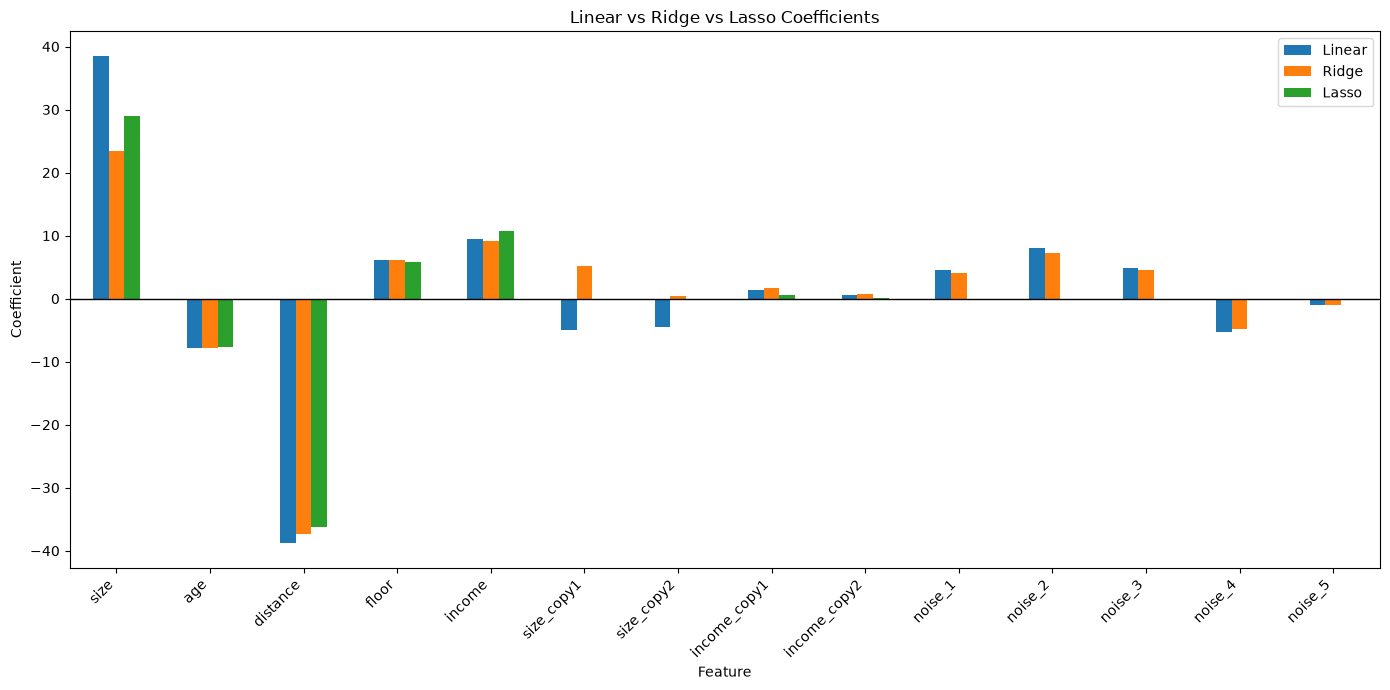

In [ ]:
# ============================================================
# 8. 畫 coefficient 比較圖
# ============================================================

coef_plot = coef_df.set_index('Feature')

coef_plot.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.ylabel('Coefficient')

plt.title(
    'Linear vs Ridge vs Lasso Coefficients'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()

plt.show()

# Linear：全部都用。
# Ridge：全部保留，但把係數壓小。
# Lasso：有些特徵直接不要。

## ElasticNet and Regularization 

### Getting ready
In order to implement ElasticNet regression, we'll use the ElasticNet class from the sklearn.linear_model module. This class is similar to Ridge and Lasso regression, but it combines their strengths to handle different types of data. We can use the same dataset created in the previous section to demonstrate the implementation of ElasticNet regression.   
結合 Ridge 和 Lasso的特點


### How to do it
We will create a range of `alpha` and `l1_ratio` values to test and plot the coefficient paths for each combination. This is the main purpose of ElasticNet, to handle the multicollinearity and high-dimensional data that is common in real-world datasets. The resulting visualization is called a "coefficient path plot" and it shows the relationship between the alpha and the coefficient for each feature.

In [ ]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=123
)

elastic_model.fit(X_train, y_train)
# 把 ElasticNet coefficient 加到原本 coef_df

coef_df['ElasticNet'] = elastic_model.coef_

display(coef_df)

,Feature,Linear,Ridge,Lasso,ElasticNet
0,size,38.543464,23.426846,28.926988,15.153963
1,age,-7.870091,-7.879184,-7.680490,-7.812042
2,distance,-38.842479,-37.303126,-36.305481,-33.793545
3,floor,6.070522,6.078296,5.811105,6.023778
4,income,9.541013,9.177105,10.739813,8.243907
5,size_copy1,-4.934987,5.156607,0.000000,9.252861
6,size_copy2,-4.540092,0.443235,0.000000,4.561488
7,income_copy1,1.356125,1.639149,0.596964,2.219859
8,income_copy2,0.624168,0.706768,0.142725,1.033640
9,noise_1,4.485327,4.112784,0.000000,2.666431


In [ ]:
l1_ratio = 0.5

# 因為 coefficient 太大，代表模型對某個 feature 的變化「反應太激烈」。這通常會讓模型容易把訓練資料裡的偶然雜訊也當成真正規律，造成 overfitting。
# 透過調整alpha，我們可以讓模型對 feature 的變化「反應比較溫和」，降低 overfitting 的風險。
alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

coefs = []

for alpha in alphas:
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=123
    )

    model.fit(X_train, y_train)
    coefs.append(model.coef_)

coef_alpha_df = pd.DataFrame(
    np.array(coefs).T,
    index=X.columns,
    columns=alphas
)

# 欄位名稱改得更清楚

coef_alpha_df.columns = [
    f'alpha={alpha}'
    for alpha in alphas
]

display(coef_alpha_df.round(2))

# alpha 越大，對 coefficient 的壓縮力量越強

,alpha=0.0001,alpha=0.001,alpha=0.01,alpha=0.1,alpha=1,alpha=10,alpha=100
size,38.53,38.41,37.23,29.66,15.15,10.04,7.63
age,-7.87,-7.87,-7.87,-7.88,-7.81,-7.03,-3.32
distance,-38.84,-38.83,-38.76,-38.15,-33.79,-15.89,-1.79
floor,6.07,6.07,6.07,6.08,6.02,5.20,1.73
income,9.54,9.54,9.53,9.40,8.24,5.20,3.57
size_copy1,-4.93,-4.84,-4.00,1.11,9.25,9.65,7.61
size_copy2,-4.54,-4.50,-4.16,-1.72,4.56,8.69,7.51
income_copy1,1.36,1.36,1.37,1.48,2.22,3.71,3.50
income_copy2,0.62,0.62,0.63,0.65,1.03,2.39,3.12
noise_1,4.49,4.48,4.47,4.32,2.67,0.00,0.00


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# 轉成 numpy array
coefs_array = np.array(coefs)

# ============================================================
# 整理成 Plotly 容易使用的 DataFrame
# ============================================================

plot_data = []

for i, feature in enumerate(X.columns):

    for j, alpha in enumerate(alphas):

        plot_data.append({
            'Feature': feature,
            'Alpha': alpha,
            'log10(Alpha)': np.log10(alpha),
            'Coefficient': coefs_array[j, i]
        })

plot_df = pd.DataFrame(plot_data)


# ============================================================
# 使用 Plotly 畫 Coefficient Path
# ============================================================

fig = px.line(
    plot_df,
    x='log10(Alpha)',
    y='Coefficient',
    color='Feature',
    markers=True,
    hover_data={
        'Alpha': True,
        'log10(Alpha)': False,
        'Coefficient': ':.2f'
    },
    title='ElasticNet Coefficient Path (l1_ratio = 0.5)',
    width=1100,
    height=700
)


# 加上 coefficient = 0 的水平線
fig.add_hline(
    y=0,
    line_width=1
)


# 軸標題
fig.update_xaxes(
    title='log10(alpha)'
)

fig.update_yaxes(
    title='Coefficient'
)

fig.show()

In [ ]:
alpha = 1

l1_ratios = [
    0.1,
    0.3,
    0.5,
    0.7,
    0.9
]

results = []

for ratio in l1_ratios:

    model = ElasticNet(
        alpha=1,
        l1_ratio=ratio,
        max_iter=10000,
        random_state=123
    )

    model.fit(X_train, y_train)

    zero_count = np.sum(model.coef_ == 0)

    results.append({
        'l1_ratio': ratio,
        'Zero Coefficients': zero_count
    })

ratio_df = pd.DataFrame(results)

display(ratio_df)

,l1_ratio,Zero Coefficients
0,0.1,0
1,0.3,0
2,0.5,0
3,0.7,0
4,0.9,1


## Polynomial Regression 

### Getting ready
Let’s move on and explore polynomial regression (including spline interpolation). These methods extend the capabilities of traditional linear regression, allowing for more flexible modeling of complex relationships in data. By implementing these techniques, you can expand your toolbox of approaches to regression problems..

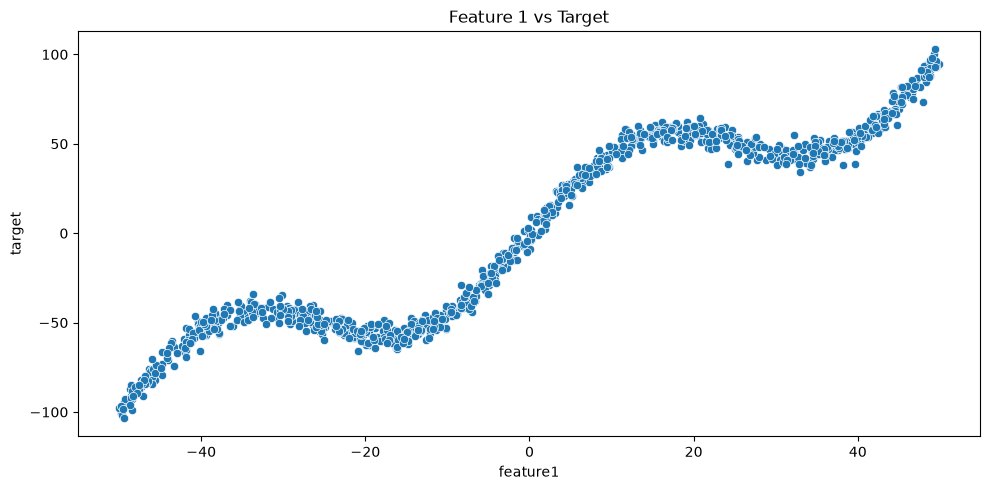

In [ ]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create synthetic dataset with non-linear relationships
np.random.seed(123)
n_samples = 1000
X = np.random.uniform(-50, 50, (n_samples, 1))

# Create target with non-linear components:
y = (2 * X[:, 0]  # linear component
     + 27 * np.sin(X[:, 0] / 8)  
     + np.random.normal(0, 4, n_samples))  # noise

# Create DataFrame
data = pd.DataFrame(X, columns=['feature1'])
data['target'] = y

# Create plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()

### How to do it...
In the code below, we will create a list of polynomial degrees to try and then fit a linear regression model on the polynomial features. We will then evaluate the model's performance using mean squared error (MSE) and R-squared (R^2) metrics. Finally, we will visualize the different polynomial fits and the residuals for the best performing model. Keep in mind that the best performing model is not always the one with the highest R-squared value, but rather the one that best fits the data and has the lowest mean squared error. Also, the visualization is a bit messy, but it's a good starting point (you probably won't come across a dataset with such a clean relationship between the features and the target with a perfect sine wave nonlinearity, anyway).

In [ ]:
# Load libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Use the synthetic dataset created above
X = data[['feature1']]  
y = data['target']

# Create a list of polynomial degrees to try
degrees = [1, 2, 3, 4, 5]
results = []

# Try different polynomial degrees
for degree in degrees:
    # Transform features to polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=123)
    
    # Create and fit Linear Regression model on polynomial features
    poly_model = LinearRegression()
    poly_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = poly_model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({
        'Degree': degree,
        'MSE': mse,
        'R2': r2
    })

# Create DataFrame of results
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df.to_string(index=False))




Model Performance Metrics:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5 811.070884 0.721464


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# ============================================================
# 1. 建立圖表
# ============================================================

fig = go.Figure()


# ============================================================
# 2. 畫原始資料
# ============================================================

fig.add_trace(
    go.Scatter(
        x=X['feature1'],
        y=y,
        mode='markers',
        name='Data Points',
        showlegend=True,
        marker=dict(
            size=5,
            opacity=0.25
        )
    )
)


# ============================================================
# 3. 建立平滑的 X
# ============================================================

# 注意：
# 因為原本 X 是 DataFrame
# 所以 X_plot 也建立成 DataFrame
# 而且欄位名稱一樣叫 feature1

X_plot = pd.DataFrame({
    'feature1': np.linspace(
        X['feature1'].min(),
        X['feature1'].max(),
        1000
    )
})


# ============================================================
# 4. Polynomial Regression
# ============================================================

for degree in degrees:
    poly = PolynomialFeatures(
        degree=degree
    )

    # --------------------------------------------------------
    # 4-2 把原始 X 轉換成多項式特徵
    # --------------------------------------------------------

    # Degree 1
    # 1, x
    #
    # Degree 2
    # 1, x, x²
    #
    # Degree 3
    # 1, x, x², x³
    #
    # 依此類推

    X_poly = poly.fit_transform(X)

    # --------------------------------------------------------
    # 4-3 建立 Linear Regression
    # --------------------------------------------------------

    model = LinearRegression()


    # --------------------------------------------------------
    # 4-4 訓練
    # --------------------------------------------------------

    model.fit(
        X_poly,
        y
    )


    # --------------------------------------------------------
    # 4-5 把畫圖用的 X_plot 做相同轉換
    # --------------------------------------------------------

    # 注意：
    # poly 已經用 X fit 過了
    # 所以新的 X_plot 只需要 transform

    X_plot_poly = poly.transform(
        X_plot
    )


    # --------------------------------------------------------
    # 4-6 預測 1000 個平滑點
    # --------------------------------------------------------

    y_plot = model.predict(
        X_plot_poly
    )


    # --------------------------------------------------------
    # 4-7 加到 Plotly
    # --------------------------------------------------------

    fig.add_trace(
        go.Scatter(

            # ★ X_plot 現在是 DataFrame
            # 所以不能再寫 X_plot[:, 0]
            x=X_plot['feature1'],

            y=y_plot,

            mode='lines',

            # Legend 名稱
            name=f'Degree {degree}',

            showlegend=True,

            line=dict(
                width=3
            )
        )
    )


# ============================================================
# 5. 設定圖表
# ============================================================

fig.update_layout(

    title='Polynomial Regression Fits',

    xaxis_title='Feature 1',

    yaxis_title='Target',

    width=1200,

    height=700,

    # 顯示 Legend
    showlegend=True,

    # Legend 放右側
    legend=dict(
        title='選擇模型',
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top'
    ),

    # 右邊留空間
    margin=dict(
        r=180
    )
)


# ============================================================
# 6. 顯示
# ============================================================

fig.show()

### Spline Interpolation 
Spline interpolation is a technique used to create a smooth curve that passes through a set of data points. It is a type of interpolation that uses piecewise polynomials to approximate the data. The basic idea is to divide the data into segments, and then fit a polynomial to each segment. The resulting curve is smooth and continuous at the points where the segments meet.

scikit-learn provides a SplineTransformer class that can be used to create spline interpolation. This class allows you to specify the number of "knots" (the points where the segments meet) and the degree of the polynomial to use for each segment. The SplineTransformer class is part of the sklearn.preprocessing module.  

分段區分資料，再進行迴歸分析

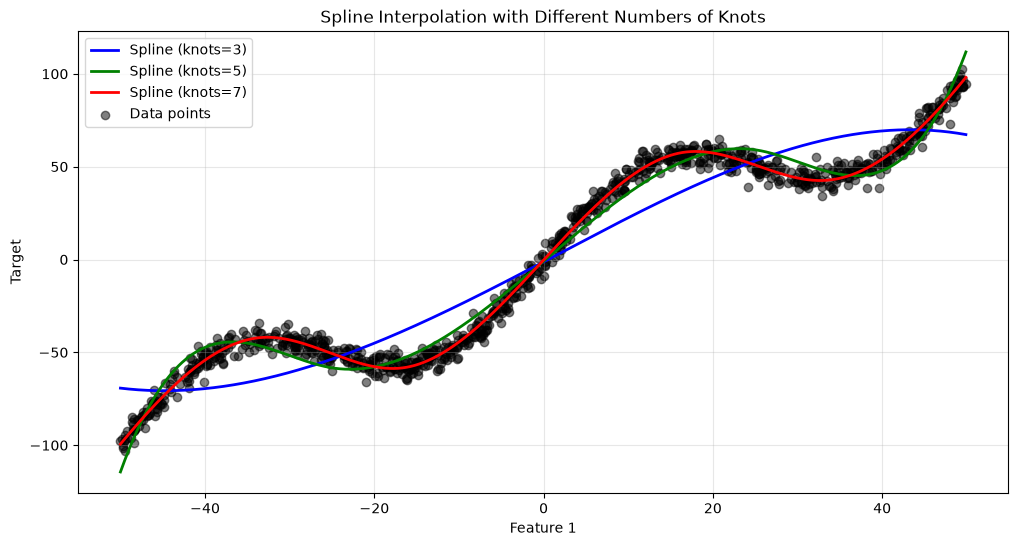

,Number of Knots,MSE,R-squared
0,3,274.267019,0.904652
1,5,55.347798,0.980759
2,7,15.502097,0.994611


In [ ]:
# Load libraries
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Create a spline transformer with different degrees of freedom
n_knots = [3, 5, 7]  # Different numbers of knots to try
plt.figure(figsize=(12, 6))

# Create lists to store metrics
mse_scores = []
r2_scores = []

colors = ['blue', 'green', 'red', 'purple', 'black']

for n_knot, color in zip(n_knots, colors[:len(n_knots)]):
    # Create and fit spline transformer
    # 先做一個資料轉換器
    # 每一小段使用三次多項式作為基礎。
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    model = make_pipeline(spline, LinearRegression())
    model.fit(X, y)
    
    # Generate predictions
    y_pred = model.predict(X_plot)
    y_pred_train = model.predict(X)
    
    # Calculate metrics
    mse = mean_squared_error(y, y_pred_train)
    r2 = r2_score(y, y_pred_train)
    mse_scores.append(mse)
    r2_scores.append(r2)
    
    # Plot the results
    plt.plot(X_plot, y_pred, 
             label=f'Spline (knots={n_knot})', 
             color=color, 
             linewidth=2)

# Plot original data points
plt.scatter(X, y, color='black', alpha=0.5, label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create and display metrics DataFrame
metrics_df = pd.DataFrame({
    'Number of Knots': n_knots,
    'MSE': mse_scores,
    'R-squared': r2_scores
})
display(metrics_df)
